In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataset_vendas_loja_ficticia.csv")

print(df.head(10))

         Data      Produto         Categoria  Preço Unitário  \
0  2023-01-20     Notebook       Eletrônicos         4285.65   
1  2023-09-24    Cafeteira  Eletrodomésticos         1355.80   
2  2023-08-07     Sandália          Calçados         3939.38   
3  2023-11-21    Cafeteira  Eletrodomésticos          580.30   
4  2023-10-20   Smartphone       Eletrônicos         2467.46   
5  2023-10-09  Camisa Polo            Roupas          807.72   
6  2023-08-07  Camisa Polo            Roupas         2089.06   
7  2023-10-11  Calça Jeans            Roupas         2021.49   
8  2023-05-15     Sandália          Calçados         3160.32   
9  2023-01-23  Calça Jeans            Roupas         1758.26   

   Quantidade Vendida  Receita Total Forma de Pagamento        Região  
0                   2        8571.30           Dinheiro           Sul  
1                  10       13558.00           Dinheiro  Centro-Oeste  
2                   8       31515.04                Pix         Norte  
3      

Análise de Preço Médio por Categoria

          Categoria  Preço Unitário
0          Calçados     2553.153125
1  Eletrodomésticos     2428.350213
2       Eletrônicos     2448.975000
3            Roupas     2561.440980


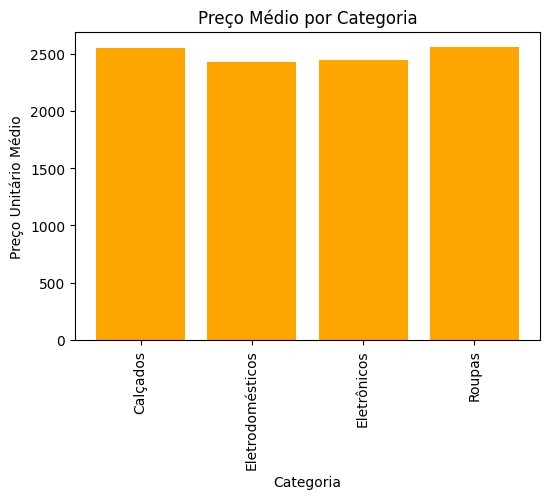

In [29]:
preco_medio_categoria = df.groupby('Categoria')['Preço Unitário'].mean().reset_index()

print(preco_medio_categoria)

plt.figure(figsize=(6, 4))
plt.bar(preco_medio_categoria['Categoria'], preco_medio_categoria['Preço Unitário'], color='orange')
plt.title('Preço Médio por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Preço Unitário Médio')
plt.xticks(rotation=90)
plt.show()

Análise de Vendas Totais por Região

         Região  Receita Total
0  Centro-Oeste      514533.76
1      Nordeste      437875.60
2         Norte      544973.83
3       Sudeste      387441.41
4           Sul      615709.02


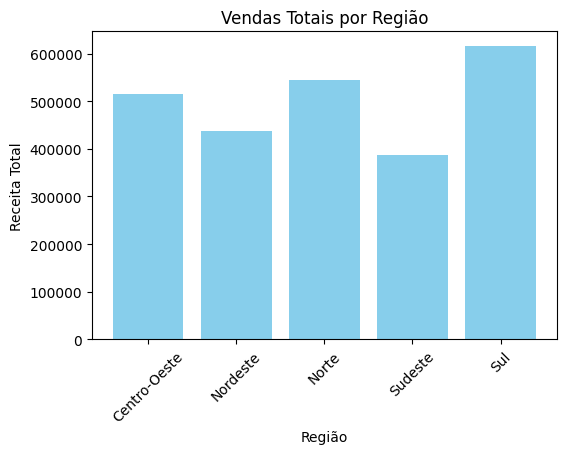

In [21]:
vendas_totais_regiao = df.groupby('Região')['Receita Total'].sum().reset_index()

print(vendas_totais_regiao)

plt.figure(figsize=(6, 4))
plt.bar(vendas_totais_regiao['Região'], vendas_totais_regiao['Receita Total'], color='skyblue')
plt.title('Vendas Totais por Região')
plt.xlabel('Região')
plt.ylabel('Receita Total')
plt.xticks(rotation=45)
plt.show()

Análise de Vendas Totais por Forma de Pagamento

  Forma de Pagamento  Receita Total
0  Cartão de Crédito      583224.80
1   Cartão de Débito      749683.15
2           Dinheiro      672475.78
3                Pix      495149.89


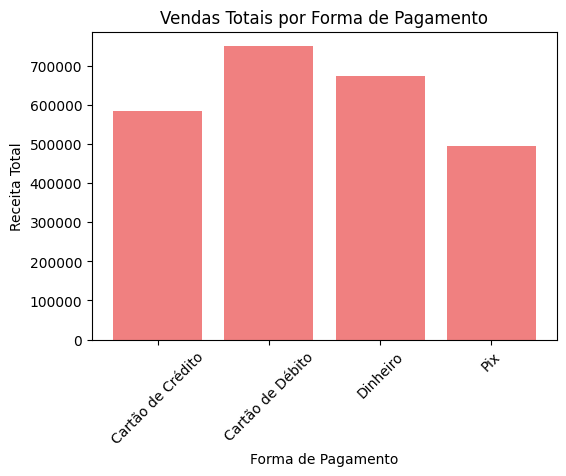

In [23]:
vendas_totais_pagamento = df.groupby('Forma de Pagamento')['Receita Total'].sum().reset_index()

print(vendas_totais_pagamento)

plt.figure(figsize=(6, 4))
plt.bar(vendas_totais_pagamento['Forma de Pagamento'], vendas_totais_pagamento['Receita Total'], color='lightcoral')
plt.title('Vendas Totais por Forma de Pagamento')
plt.xlabel('Forma de Pagamento')
plt.ylabel('Receita Total')
plt.xticks(rotation=45)
plt.show()

Análise de Produtos Mais Vendidos

           Produto  Receita Total
0        Cafeteira      329235.38
1      Calça Jeans      387985.98
2      Camisa Polo      322295.80
3   Liquidificador      269000.31
4         Notebook      268320.65
5         Sandália      213163.78
6       Smartphone      384547.78
7  Tênis Esportivo      325983.94


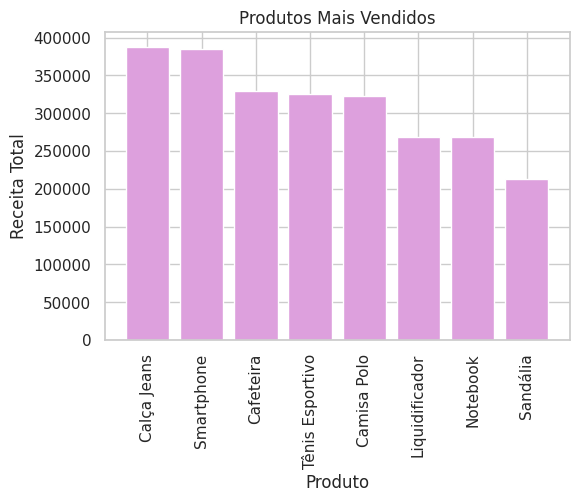

In [53]:
produtos_mais_vendidos = df.groupby('Produto')['Receita Total'].sum().reset_index()

print(produtos_mais_vendidos)

produtos_mais_vendidos = produtos_mais_vendidos.sort_values(by='Receita Total', ascending=False)

plt.figure(figsize=(6, 4))
plt.bar(produtos_mais_vendidos['Produto'], produtos_mais_vendidos['Receita Total'], color='plum')
plt.title('Produtos Mais Vendidos')
plt.xlabel('Produto')
plt.ylabel('Receita Total')
plt.xticks(rotation=90)
plt.show()

Análise de Vendas Totais por Categoria

          Categoria  Lucro por Produto
3            Roupas          710281.78
2       Eletrônicos          652868.43
1  Eletrodomésticos          598235.69
0          Calçados          539147.72


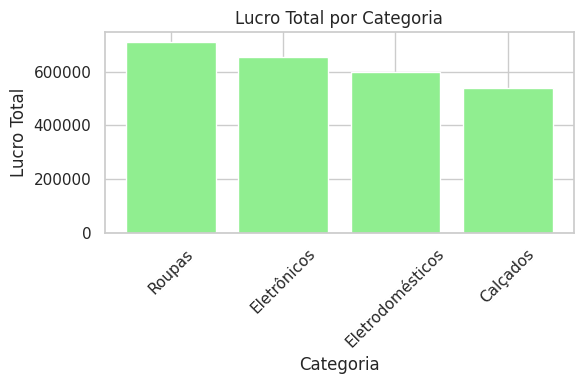

In [47]:
df['Lucro por Produto'] = df['Preço Unitário'] * df['Quantidade Vendida']

lucro_categoria = df.groupby('Categoria')['Lucro por Produto'].sum().reset_index()

lucro_categoria = lucro_categoria.sort_values(by='Lucro por Produto', ascending=False)

print(lucro_categoria)

plt.figure(figsize=(6, 4))
plt.bar(lucro_categoria['Categoria'], lucro_categoria['Lucro por Produto'], color='lightgreen')
plt.title('Lucro Total por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Lucro Total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Evolução da Receita Total por Mês e Ano

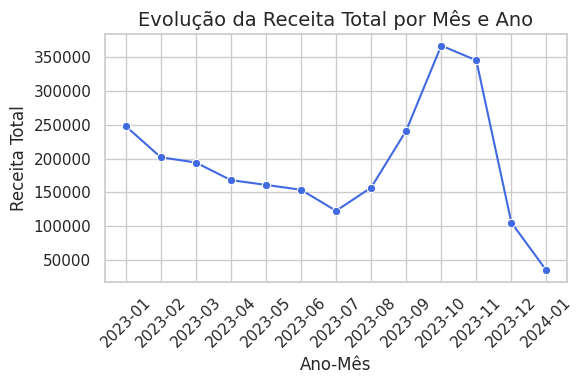

In [36]:
df['Data'] = pd.to_datetime(df['Data'])

df['Ano'] = df['Data'].dt.year
df['Mês'] = df['Data'].dt.month

vendas_por_mes_ano = df.groupby(['Ano', 'Mês'])['Receita Total'].sum().reset_index()

vendas_por_mes_ano['Ano-Mês'] = vendas_por_mes_ano['Ano'].astype(str) + '-' + vendas_por_mes_ano['Mês'].astype(str).str.zfill(2)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.lineplot(data=vendas_por_mes_ano, x='Ano-Mês', y='Receita Total', marker='o', color='royalblue')
plt.title('Evolução da Receita Total por Mês e Ano', fontsize=14)
plt.xlabel('Ano-Mês')
plt.ylabel('Receita Total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 10 Produtos Mais Lucrativos

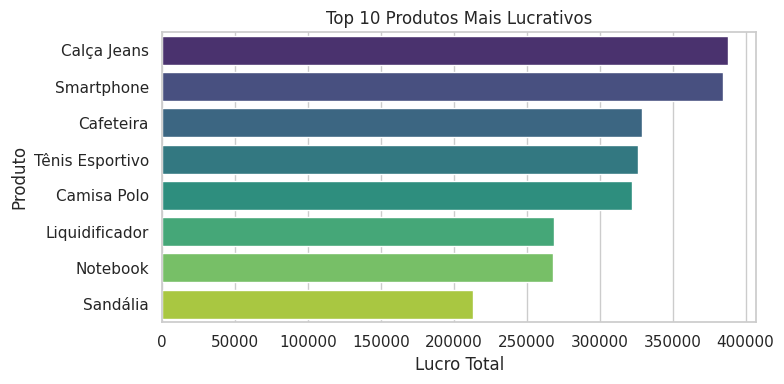

In [40]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=produtos_lucrativos.head(10),
    x='Lucro por Produto',
    y='Produto',
    hue='Produto',
    dodge=False,
    palette='viridis',
    legend=False
)
plt.title('Top 10 Produtos Mais Lucrativos')
plt.xlabel('Lucro Total')
plt.ylabel('Produto')
plt.tight_layout()
plt.show()

Lucro para cada produto (venda bruta)

          Categoria  Lucro por Produto
3            Roupas          710281.78
2       Eletrônicos          652868.43
1  Eletrodomésticos          598235.69
0          Calçados          539147.72


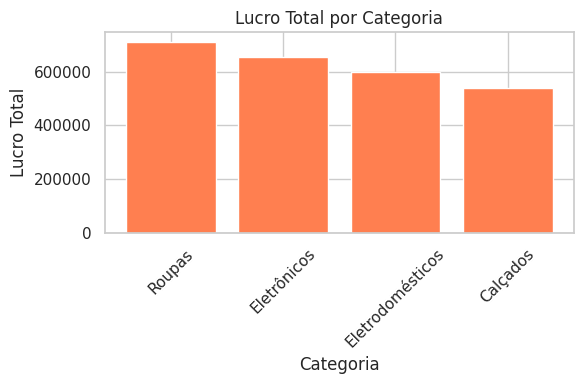

In [54]:
df['Lucro por Produto'] = df['Preço Unitário'] * df['Quantidade Vendida']

lucro_categoria = df.groupby('Categoria')['Lucro por Produto'].sum().reset_index()

lucro_categoria = lucro_categoria.sort_values(by='Lucro por Produto', ascending=False)

print(lucro_categoria)

plt.figure(figsize=(6, 4))
plt.bar(lucro_categoria['Categoria'], lucro_categoria['Lucro por Produto'], color='coral')
plt.title('Lucro Total por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Lucro Total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [55]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
